# ForecastLab

---

## Bike Sharing Demand Forecasting

---

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-001 |
| **Eksperimen** | EXP-008 |
| **Nama Eksperimen** | Decision Tree |
| **Dataset** | featured_data.csv |
| **Tujuan Notebook** | Membandingkan model non-linear pertama dengan Linear Regression |
| **Author** | GAKUSEI Najib |

---

## 1. Tujuan Eksperimen

### Tujuan
Membangun Decision Tree Regressor untuk menangkap hubungan non-linear.

### Hipotesis
Decision Tree mampu menangkap hubungan non-linear yang tidak dapat dipelajari oleh Linear Regression.

---
## 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
print('Library berhasil diimport.')

Library berhasil diimport.


---
## 3. Load & Prepare Dataset

In [2]:
INPUT_PATH = '../data/featured_data.csv'
df = pd.read_csv(INPUT_PATH)
df['dteday'] = pd.to_datetime(df['dteday'])
df = df.sort_values(by=['dteday', 'hr']).reset_index(drop=True)

exclude_cols = ['dteday', 'cnt', 'temp_actual', 'atemp_actual']
feature_cols = [c for c in df.columns if c not in exclude_cols]

train = df[df['yr'] == 0].copy()
test  = df[df['yr'] == 1].copy()

X_train = train[feature_cols].copy()
y_train = train['cnt'].copy()
X_test  = test[feature_cols].copy()
y_test  = test['cnt'].copy()

train_valid = X_train.dropna().index
X_train = X_train.loc[train_valid]
y_train = y_train.loc[train_valid]
test_valid = X_test.dropna().index
X_test = X_test.loc[test_valid]
y_test = y_test.loc[test_valid]

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (8477, 41), X_test: (8734, 41)


---
## 4. Train Decision Tree

In [3]:
model_dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
model_dt.fit(X_train, y_train)

y_pred_train = model_dt.predict(X_train)
y_pred_test  = model_dt.predict(X_test)
print('Decision Tree berhasil dilatih.')

Decision Tree berhasil dilatih.


---
## 5. Evaluation

In [4]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

df_metrics = pd.DataFrame([
    evaluate('Decision Tree (Train)', y_train, y_pred_train),
    evaluate('Decision Tree (Test)', y_test, y_pred_test)
])
print(df_metrics.to_string(index=False))

                Model       MAE      RMSE      MAPE       R2
Decision Tree (Train) 16.090763 25.284820 22.692510 0.964578
 Decision Tree (Test) 59.837641 98.187912 33.537344 0.779076


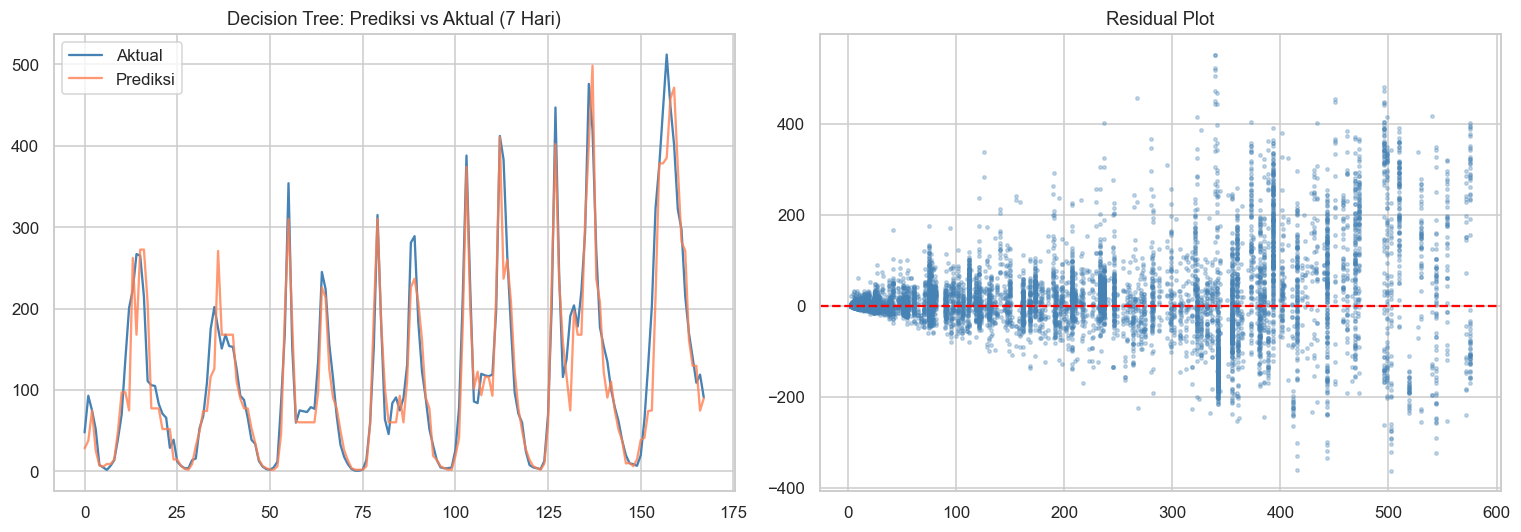

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_show = 168
axes[0].plot(range(n_show), y_test.values[:n_show], label='Aktual', color='steelblue')
axes[0].plot(range(n_show), y_pred_test[:n_show], label='Prediksi', color='coral', alpha=0.8)
axes[0].set_title('Decision Tree: Prediksi vs Aktual (7 Hari)')
axes[0].legend()

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.3, s=5, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('../data/dt_01_prediction.png', bbox_inches='tight', dpi=110)
plt.show()

## 6. Kesimpulan

**Insight:**
- Decision Tree menangkap pola non-linear lebih baik dari Linear Regression.
- Rentan overfitting jika `max_depth` terlalu besar.

**Next: EXP-009 Random Forest**